# Social Media Impact on Student Life — Predicting Overall Impact
## Semester Project · Part 1: Data Preparation & Leakage-Free Pipeline

**Group:** _<group name / members / roll numbers>_  
**GitHub repo:** _<link>_

Social media is now part of daily student life, and its effect can be helpful, neutral, or harmful. This project investigates whether a student's **usage habits and basic profile** can predict the **overall impact** of social media on that student, so that students at risk could be supported early.

**Task:** Multiclass classification (3 ordered classes)  
**Target:** `Overall_Impact`  
**Class 0 – Negative:** social media is harming the student  
**Class 1 – Neutral:** no clear effect  
**Class 2 – Beneficial:** social media is helping the student  
**Primary future metric:** macro-averaged F1-score, supported by per-class recall (especially for *Negative*), balanced accuracy, accuracy, and one-vs-rest ROC-AUC.

This Part 1 section covers data preparation and preprocessing only; it does not train a predictive model.

> **AI-assistance disclosure:** This notebook was drafted with help from Claude (Anthropic). All group members have reviewed, run and understood the code, as required for the viva.

## Optional setup for Google Colab

If you run this notebook in Google Colab, uncomment and run the next cell once, then upload `Social_media_impact_on_life.csv` to the session. In VS Code or another local environment, skip it and install the same packages from `requirements.txt`.

In [1]:
# %pip install pandas numpy matplotlib scikit-learn

## 1. Imports and data loading

The raw data remains in `df_raw`. The path search supports running the notebook from the project root, from the `notebook` folder, or from the folder that contains the CSV.

In [2]:
# Import the libraries used for data loading, summaries, charts, and preprocessing.
from pathlib import Path
import csv
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler

# Fix the random seed so every run produces the same split.
RANDOM_STATE = 42
# Name of the dataset file.
FILE_NAME = "Social_media_impact_on_life.csv"
# Look for the file in the usual project locations.
candidate_paths = [Path("../data") / FILE_NAME, Path("data") / FILE_NAME, Path(FILE_NAME)]
# Use the first path that exists.
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
# Stop early with a clear error if the dataset cannot be found.
assert DATA_PATH is not None, f"Dataset not found. Tried: {[str(p) for p in candidate_paths]}"

# Read the CSV with pandas' default missing-value parsing.
df_raw = pd.read_csv(DATA_PATH)
# Print the loaded row and column count using an f-string.
print(f"Loaded {DATA_PATH}: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

Loaded Social_media_impact_on_life.csv: 4,500 rows × 16 columns


## 2. Raw missing-value representation

Before choosing a missing-value policy, inspect the source CSV tokens. The data above was loaded with pandas' normal defaults; no custom `na_values` option is forced.

In [3]:
# Count raw missing-value tokens before relying on pandas' default parsing.
# Tokens that sometimes stand for "missing" in survey and web-scraped data.
missing_tokens = ["", "NA", "N/A", "NULL", "null", "NaN", "nan", "None", "?", "-"]
# Counter keyed by (column, token) for every suspicious cell.
token_counter = Counter()
# Read raw CSV text so tokens can be checked before pandas converts them.
with DATA_PATH.open(newline="", encoding="utf-8") as csv_file:
    # Examine every row in the raw CSV.
    for row in csv.DictReader(csv_file):
        # Check each cell against the list of missing-value tokens.
        for column, value in row.items():
            if value is not None and value.strip() in missing_tokens:
                # Show an empty cell as "(empty)" so it is visible in the table.
                token_counter[(column, value.strip() or "(empty)")] += 1

# Display the token table (or state that none were found).
if token_counter:
    raw_token_counts = pd.Series(token_counter).unstack(fill_value=0)
    display(raw_token_counts)
    affected = " and ".join(f"`{c}`" for c in raw_token_counts.index)
    display(Markdown(f"**Decision.** Missing cells appear only in {affected}, and they are stored as empty fields. Pandas converts empty fields to `NaN` with its default parser, so no custom parsing argument is needed."))
else:
    display(Markdown("**Decision.** No missing-value tokens were found in the raw file."))

,(empty)
Academic_Performance_GPA,85
Perceived_Stress_Score,46


**Decision.** Missing cells appear only in `Academic_Performance_GPA` and `Perceived_Stress_Score`, and they are stored as empty fields. Pandas converts empty fields to `NaN` with its default parser, so no custom parsing argument is needed.

## 3. Data understanding

Inspect the supplied data before making any cleaning decisions.

In [4]:
# Summarize the raw dataset's rows, columns, data types, and distributions.
# Preview the first five raw records.
display(df_raw.head())
# Build a feature table with type, uniqueness, and missingness information.
feature_summary = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "unique_values": df_raw.nunique(dropna=True),
    "missing_count": df_raw.isna().sum(),
    "missing_percent": (df_raw.isna().mean() * 100).round(2),
}).sort_values(["missing_percent", "unique_values"], ascending=[False, False])
# Show features ordered from most to least missing.
display(feature_summary)
# Show descriptive statistics for numeric and categorical features.
display(df_raw.describe(include="all").T)

,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact
0,STU_2024000,19,Female,Undergraduate,Snapchat,7.5,1.5,Smartphone,5.9,2,True,Always,20.0,73,2.73,Neutral
1,STU_2024001,19,Female,Undergraduate,Instagram,4.6,1.3,Smartphone,7.9,3,True,Sometimes,17.0,90,3.21,Beneficial
2,STU_2024002,17,Female,High School,TikTok,10.9,1.7,Smartphone,5.2,1,True,Frequently,18.0,70,3.00,Neutral
3,STU_2024003,16,Female,High School,YouTube,6.0,2.3,Tablet,7.6,4,True,Sometimes,15.0,82,3.42,Beneficial
4,STU_2024004,17,Male,High School,LinkedIn,3.3,2.6,Smartphone,7.6,4,True,Never,16.0,84,3.41,Beneficial


,dtype,unique_values,missing_count,missing_percent
Academic_Performance_GPA,float64,194,85,1.89
Perceived_Stress_Score,float64,41,46,1.02
Student_ID,str,4500,0,0.00
Daily_Usage_Hours,float64,129,0,0.00
Sleep_Duration_Hours,float64,73,0,0.00
Mental_Health_Index,int64,67,0,0.00
Weekend_Extra_Hours,float64,43,0,0.00
Age,int64,12,0,0.00
Primary_Platform,str,7,0,0.00
Sleep_Quality_Score,int64,5,0,0.00


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,4500,4500,STU_2024000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,4500.0,NaN,NaN,NaN,18.703333,1.981182,15.0,17.0,19.0,20.0,26.0
Gender,4500,4,Female,2234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Academic_Level,4500,3,Undergraduate,2777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Primary_Platform,4500,7,Instagram,1453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Daily_Usage_Hours,4500.0,NaN,NaN,NaN,5.295933,2.604497,0.9,3.4,4.7,6.6,14.0
Weekend_Extra_Hours,4500.0,NaN,NaN,NaN,1.796844,0.699245,0.0,1.3,1.8,2.3,4.5
Device_Type,4500,3,Smartphone,3775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Duration_Hours,4500.0,NaN,NaN,NaN,6.701333,1.189998,3.0,6.0,6.8,7.5,10.5
Sleep_Quality_Score,4500.0,NaN,NaN,NaN,2.472,1.030484,1.0,2.0,3.0,3.0,5.0


### Identifiers and duplicate records

`Student_ID` is a unique label, not a behaviour, so it cannot generalise to new students and is dropped later. Exact duplicate rows are checked as an evaluation safeguard: otherwise the same record could occur in both train and test data and overstate future performance.

In [5]:
# Check whether the identifier is unique and whether any record is repeated.
# Confirm that every Student_ID occurs once.
id_is_unique = df_raw["Student_ID"].is_unique
# Count rows identical to an earlier row.
duplicate_count = int(df_raw.duplicated().sum())
# Count rows that match another student on every column except the ID.
duplicate_without_id = int(df_raw.drop(columns="Student_ID").duplicated().sum())
# Print the results using f-strings.
print(f"Student_ID is unique: {id_is_unique}")
print(f"Exact duplicate rows: {duplicate_count:,} ({duplicate_count / len(df_raw):.2%})")
print(f"Duplicates ignoring Student_ID: {duplicate_without_id:,}")

Student_ID is unique: True
Exact duplicate rows: 0 (0.00%)
Duplicates ignoring Student_ID: 0


### Missing values and categorical features

Missing values are examined by feature meaning, and by group, before an imputation policy is chosen. Categorical features are small, so no rare-category grouping is needed.

In [6]:
# Review missingness and category sizes to understand data quality.
# Keep only features that contain at least one missing value.
missing_summary = feature_summary.loc[feature_summary["missing_count"] > 0, ["missing_count", "missing_percent"]]
# Display the missing-data summary.
display(missing_summary)
# List the columns that contain missing values.
missing_columns = missing_summary.index.tolist()

# Check whether missingness depends on academic level (percent missing per group).
by_level = pd.DataFrame({c: df_raw.groupby("Academic_Level")[c].apply(lambda s: s.isna().mean() * 100) for c in missing_columns}).round(2)
print("Percent missing by Academic_Level:")
display(by_level)
# Check whether missingness depends on the target class (percent missing per group).
by_target = pd.DataFrame({c: df_raw.groupby("Overall_Impact")[c].apply(lambda s: s.isna().mean() * 100) for c in missing_columns}).round(2)
print("Percent missing by Overall_Impact:")
display(by_target)

# Identify text columns for categorical analysis.
categorical_columns = df_raw.select_dtypes(include=["object", "string"]).columns.drop("Student_ID").tolist()
# Summarize category counts and most common labels.
categorical_summary = pd.DataFrame({
    "unique_values": df_raw[categorical_columns].nunique(dropna=True),
    "top_category": [df_raw[c].value_counts().index[0] for c in categorical_columns],
    "top_category_share_%": [round(df_raw[c].value_counts(normalize=True).iloc[0] * 100, 1) for c in categorical_columns],
}).sort_values("unique_values", ascending=False)
# Display categorical columns from highest to lowest cardinality.
display(categorical_summary)
# Show the full value counts for the small categorical features.
for column in ["Gender", "Academic_Level", "Primary_Platform", "Device_Type", "Social_Comparison_Frequency"]:
    print(f"\nCategories for {column}:")
    display(df_raw[column].value_counts(dropna=False).rename("count").to_frame())

display(Markdown(f"**Decision.** Only {' and '.join(f'`{c}`' for c in missing_columns)} contain missing values, and the amount is small ({missing_summary['missing_percent'].max():.1f}% at most). Missingness is spread across groups rather than concentrated in one class, so values will be imputed with the **median fitted on the training split only**, with a missing-indicator flag whenever these columns are used."))

,missing_count,missing_percent
Academic_Performance_GPA,85,1.89
Perceived_Stress_Score,46,1.02


Percent missing by Academic_Level:


,Academic_Performance_GPA,Perceived_Stress_Score
Academic_Level,,
High School,1.83,1.02
Postgraduate,0.81,1.63
Undergraduate,2.02,0.97


Percent missing by Overall_Impact:


,Academic_Performance_GPA,Perceived_Stress_Score
Overall_Impact,,
Beneficial,1.93,1.03
Negative,1.21,0.61
Neutral,1.83,1.07


...


Categories for Device_Type:


,count
Device_Type,
Smartphone,3775
Laptop/PC,596
Tablet,129



Categories for Social_Comparison_Frequency:


,count
Social_Comparison_Frequency,
Sometimes,1594
Frequently,1248
Rarely,766
Always,632
Never,260


**Decision.** Only `Academic_Performance_GPA` and `Perceived_Stress_Score` contain missing values, and the amount is small (1.9% at most). Missingness is spread across groups rather than concentrated in one class, so values will be imputed with the **median fitted on the training split only**, with a missing-indicator flag whenever these columns are used.

## 4. Target, data quality, and outlier analysis

The evidence below is shown before any rows are removed. Plausible long-tailed values are retained; only physically impossible records would be removed.

,count,percent
Overall_Impact,,
Negative,165,3.67
Neutral,654,14.53
Beneficial,3681,81.80


,violations
age_outside_13_30,0
gpa_outside_0_4,0
stress_outside_0_40,0
mental_health_outside_0_100,0
sleep_quality_outside_1_5,0
daily_usage_negative_or_over_24h,0
weekend_usage_over_24h,0
sleep_plus_usage_over_24h,0


Rows breaking at least one rule: 0


Academic_Level,High School,Postgraduate,Undergraduate
Age,,,
15,164,0,0
16,340,0,0
17,716,0,0
18,101,0,927
19,74,0,828
20,52,0,578
21,30,0,326
22,0,122,56
23,0,53,32


,0.0,0.01,0.25,0.5,0.75,0.99,1.0
Age,15.0,15.00,17.0,19.00,20.00,25.0,26.0
Daily_Usage_Hours,0.9,1.50,3.4,4.70,6.60,14.0,14.0
Weekend_Extra_Hours,0.0,0.20,1.3,1.80,2.30,3.4,4.5
Sleep_Duration_Hours,3.0,3.60,6.0,6.80,7.50,9.2,10.5
Perceived_Stress_Score,0.0,0.00,9.0,13.00,18.00,33.0,40.0
Academic_Performance_GPA,1.9,2.35,3.2,3.46,3.72,4.0,4.0


,values_outside_1.5_IQR
Age,51
Daily_Usage_Hours,162
Weekend_Extra_Hours,10
Sleep_Duration_Hours,72
Perceived_Stress_Score,75
Academic_Performance_GPA,68


**Data-quality decision.** 0 rows break a plausibility rule, so none are removed for impossibility. Values outside the IQR fences exist in a few variables, but they are physically possible (for example up to 14 hours of daily use), so they are **kept** and handled with `RobustScaler` rather than deleted. 257 records are aged 18+ at *High School* level; this is plausible (late school years) and is not treated as an error.

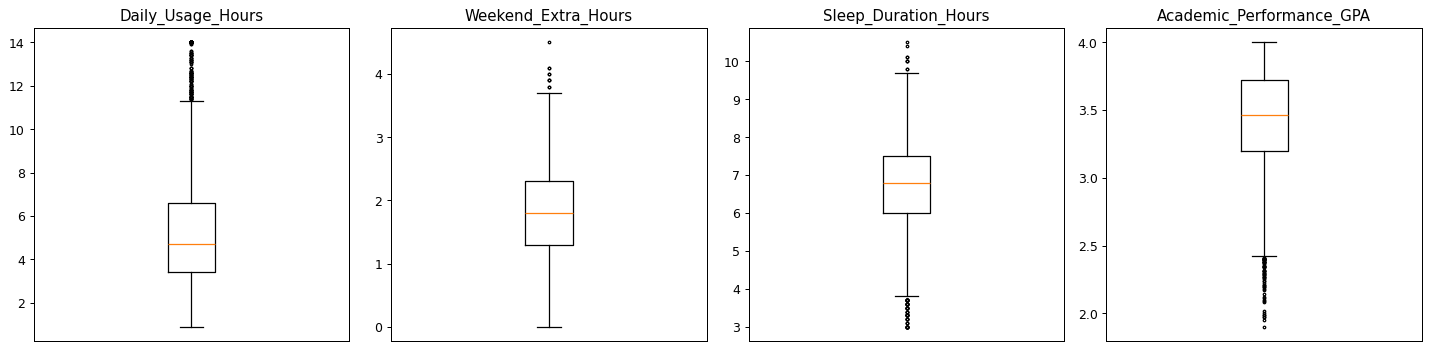

In [7]:
# Document target balance, impossible records, and plausible long-tailed values.
# Define the class order from most harmful to most helpful.
class_order = ["Negative", "Neutral", "Beneficial"]
# Count students in each target class.
target_counts_raw = df_raw["Overall_Impact"].value_counts().reindex(class_order)
# Display target counts and their percentages.
display(pd.DataFrame({"count": target_counts_raw, "percent": (target_counts_raw / len(df_raw) * 100).round(2)}))

# Define rules for impossible or implausible values (True = violation).
quality_rules = {
    "age_outside_13_30": ~df_raw["Age"].between(13, 30),
    "gpa_outside_0_4": df_raw["Academic_Performance_GPA"].notna() & ~df_raw["Academic_Performance_GPA"].between(0, 4),
    "stress_outside_0_40": df_raw["Perceived_Stress_Score"].notna() & ~df_raw["Perceived_Stress_Score"].between(0, 40),
    "mental_health_outside_0_100": ~df_raw["Mental_Health_Index"].between(0, 100),
    "sleep_quality_outside_1_5": ~df_raw["Sleep_Quality_Score"].between(1, 5),
    "daily_usage_negative_or_over_24h": ~df_raw["Daily_Usage_Hours"].between(0, 24),
    "weekend_usage_over_24h": (df_raw["Daily_Usage_Hours"] + df_raw["Weekend_Extra_Hours"]) > 24,
    "sleep_plus_usage_over_24h": (df_raw["Sleep_Duration_Hours"] + df_raw["Daily_Usage_Hours"]) > 24,
}
# Count violations for each rule.
quality_counts = pd.Series({name: int(mask.sum()) for name, mask in quality_rules.items()}, name="violations")
# Display the rule counts.
display(quality_counts.to_frame())
# Flag any row that breaks at least one rule.
invalid_rows = pd.concat(quality_rules.values(), axis=1).any(axis=1)
print(f"Rows breaking at least one rule: {int(invalid_rows.sum())}")

# Check that school level and age are broadly consistent (a plausibility check, not a removal rule).
display(pd.crosstab(df_raw["Age"], df_raw["Academic_Level"]))
adult_high_school = int(((df_raw["Academic_Level"] == "High School") & (df_raw["Age"] >= 18)).sum())

# Select continuous variables whose long tails need descriptive review.
outlier_columns = ["Age", "Daily_Usage_Hours", "Weekend_Extra_Hours", "Sleep_Duration_Hours", "Perceived_Stress_Score", "Academic_Performance_GPA"]
# Display selected quantiles instead of deleting plausible extreme values.
display(df_raw[outlier_columns].quantile([0, 0.01, 0.25, 0.5, 0.75, 0.99, 1]).T)

# Count values outside 1.5 × IQR for each variable (Tukey fences).
def iqr_outlier_count(series):
    # Drop missing values before computing quartiles.
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    # Count values beyond the lower or upper fence.
    return int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())
iqr_counts = pd.Series({c: iqr_outlier_count(df_raw[c]) for c in outlier_columns}, name="values_outside_1.5_IQR")
display(iqr_counts.to_frame())

# Create boxplots (with outliers shown) for the main continuous variables.
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, column in zip(axes, ["Daily_Usage_Hours", "Weekend_Extra_Hours", "Sleep_Duration_Hours", "Academic_Performance_GPA"]):
    ax.boxplot(df_raw[column].dropna(), flierprops={"markersize": 2})
    ax.set(title=column, xticks=[])
plt.tight_layout(); plt.show()

display(Markdown(f"**Data-quality decision.** {int(invalid_rows.sum())} rows break a plausibility rule, so none are removed for impossibility. Values outside the IQR fences exist in a few variables, but they are physically possible (for example up to {df_raw['Daily_Usage_Hours'].max():.0f} hours of daily use), so they are **kept** and handled with `RobustScaler` rather than deleted. {adult_high_school} records are aged 18+ at *High School* level; this is plausible (late school years) and is not treated as an error."))

## 5. Model-ready data and EDA

`df_model` is a separate working copy. It drops the identifier, removes exact duplicates and any impossible records (none are expected), and encodes the target as ordered integer codes. `df_raw` remains unchanged.

In [8]:
# Create the model-ready dataframe and encode the target.
# Remove exact duplicates and impossible records while preserving df_raw.
df_model = df_raw.loc[~invalid_rows].drop_duplicates().copy()
print(f"Rows kept: {len(df_model):,} of {len(df_raw):,}")
# Drop the identifier, which carries no reusable signal.
df_model = df_model.drop(columns="Student_ID")
# Store the boolean late-night flag as 0/1 so it behaves like any other binary feature.
df_model["Late_Night_Usage"] = df_model["Late_Night_Usage"].astype(int)

# Name the target and create ordered integer codes (0 = Negative, 1 = Neutral, 2 = Beneficial).
target = "Overall_Impact"
class_to_code = {name: code for code, name in enumerate(class_order)}
y = df_model[target].map(class_to_code).astype(int)
print("Target coding:", class_to_code)

Rows kept: 4,500 of 4,500
Target coding: {'Negative': 0, 'Neutral': 1, 'Beneficial': 2}


### EDA questions

The figure examines class balance, daily usage, platform, late-night use, and social comparison. For group comparisons, class **shares** are used instead of counts. The last panel shows how the numeric measurements relate to one another.

**Observations.** (1) The target is imbalanced: *Beneficial* is 81.8% of students and *Negative* only 3.7%, so accuracy alone would be misleading. (2) Median daily usage rises from 4.2 h (Beneficial) to 8.4 h (Neutral) and 12.4 h (Negative). (3) The non-beneficial share is 25.5% for late-night users and 7.9% for others. (4) By platform, the non-beneficial share is highest for LinkedIn (21.9%) and lowest for X (Twitter) (15.5%); small platform groups should be read cautiously. (5) Daily usage correlates strongly with the mental-health index (r = -0.85), while weekend extra hours are almost unrelated to daily usage (r = -0.01). These are associations, not causal effects.

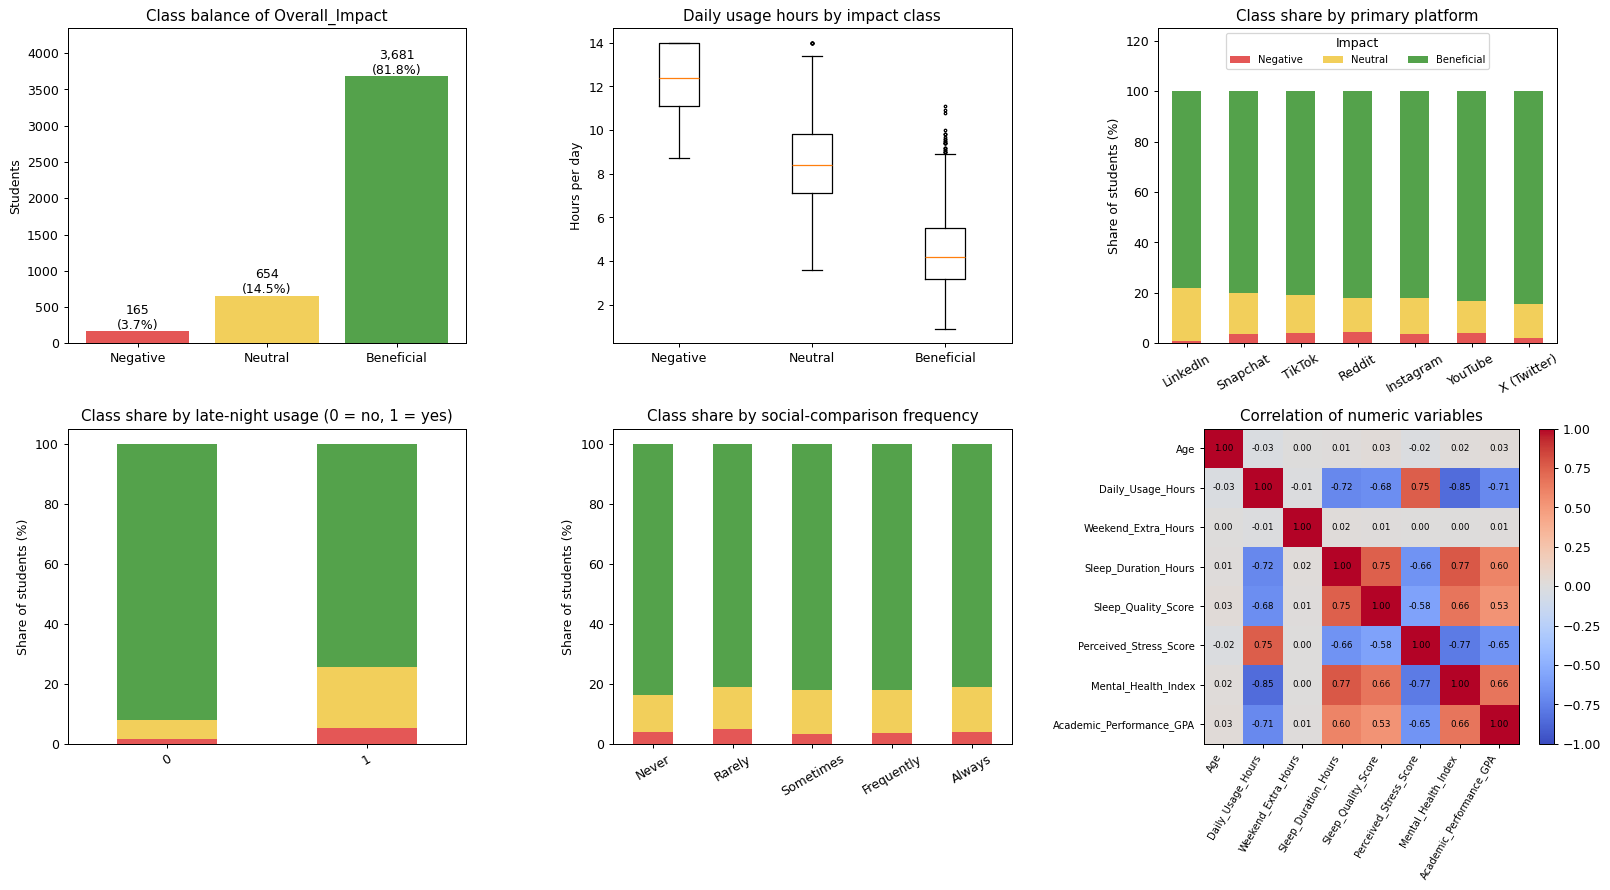

In [9]:
# Plot six descriptive views of the model-ready data and the target.
class_colors = {"Negative": "#E45756", "Neutral": "#F2CF5B", "Beneficial": "#54A24B"}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Panel 1: number of students per class.
counts = df_model[target].value_counts().reindex(class_order)
axes[0, 0].bar(counts.index, counts.values, color=[class_colors[c] for c in counts.index])
for i, value in enumerate(counts.values):
    axes[0, 0].text(i, value, f"{value:,}\n({value / len(df_model):.1%})", ha="center", va="bottom")
axes[0, 0].set(title="Class balance of Overall_Impact", ylabel="Students"); axes[0, 0].set_ylim(0, counts.max() * 1.18)

# Panel 2: daily usage hours for each class.
usage_groups = [df_model.loc[df_model[target] == c, "Daily_Usage_Hours"] for c in class_order]
axes[0, 1].boxplot(usage_groups, flierprops={"markersize": 2})
axes[0, 1].set_xticks([1, 2, 3]); axes[0, 1].set_xticklabels(class_order)
axes[0, 1].set(title="Daily usage hours by impact class", ylabel="Hours per day")

# Helper: stacked bars showing the class share inside each group.
def stacked_share(ax, column, order=None, title=""):
    shares = pd.crosstab(df_model[column], df_model[target], normalize="index")[class_order] * 100
    if order is not None:
        shares = shares.reindex(order)
    shares.plot(kind="bar", stacked=True, ax=ax, color=[class_colors[c] for c in class_order], legend=False)
    ax.set(title=title, ylabel="Share of students (%)", xlabel=""); ax.tick_params(axis="x", rotation=30)

# Panel 3: class share by primary platform (ordered by non-beneficial share).
platform_order = (df_model[target] != "Beneficial").groupby(df_model["Primary_Platform"]).mean().sort_values(ascending=False).index
stacked_share(axes[0, 2], "Primary_Platform", platform_order, "Class share by primary platform")
axes[0, 2].set_ylim(0, 125); axes[0, 2].legend(class_order, title="Impact", loc="upper center", ncol=3, fontsize=8)
# Panel 4: class share by late-night usage.
stacked_share(axes[1, 0], "Late_Night_Usage", None, "Class share by late-night usage (0 = no, 1 = yes)")
# Panel 5: class share by social-comparison frequency in natural order.
comparison_order = ["Never", "Rarely", "Sometimes", "Frequently", "Always"]
stacked_share(axes[1, 1], "Social_Comparison_Frequency", comparison_order, "Class share by social-comparison frequency")

# Panel 6: correlation heatmap of numeric variables.
numeric_for_corr = ["Age", "Daily_Usage_Hours", "Weekend_Extra_Hours", "Sleep_Duration_Hours", "Sleep_Quality_Score", "Perceived_Stress_Score", "Mental_Health_Index", "Academic_Performance_GPA"]
corr = df_model[numeric_for_corr].corr()
image = axes[1, 2].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[1, 2].set_xticks(range(len(corr))); axes[1, 2].set_xticklabels(corr.columns, rotation=60, ha="right", fontsize=8)
axes[1, 2].set_yticks(range(len(corr))); axes[1, 2].set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        axes[1, 2].text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
axes[1, 2].set_title("Correlation of numeric variables"); plt.colorbar(image, ax=axes[1, 2], fraction=0.046)
plt.tight_layout(); plt.show()

# Calculate the numbers used in the written EDA observations.
usage_medians = df_model.groupby(target)["Daily_Usage_Hours"].median().reindex(class_order)
non_beneficial = df_model[target] != "Beneficial"
late_yes, late_no = non_beneficial[df_model["Late_Night_Usage"] == 1].mean(), non_beneficial[df_model["Late_Night_Usage"] == 0].mean()
platform_rates = non_beneficial.groupby(df_model["Primary_Platform"]).mean().sort_values()
corr_usage_mh = corr.loc["Daily_Usage_Hours", "Mental_Health_Index"]
corr_weekend = corr.loc["Weekend_Extra_Hours", "Daily_Usage_Hours"]
# Display the calculated findings.
display(Markdown(
    f"**Observations.** (1) The target is imbalanced: *Beneficial* is {counts['Beneficial'] / len(df_model):.1%} of students and *Negative* only {counts['Negative'] / len(df_model):.1%}, so accuracy alone would be misleading. "
    f"(2) Median daily usage rises from {usage_medians['Beneficial']:.1f} h (Beneficial) to {usage_medians['Neutral']:.1f} h (Neutral) and {usage_medians['Negative']:.1f} h (Negative). "
    f"(3) The non-beneficial share is {late_yes:.1%} for late-night users and {late_no:.1%} for others. "
    f"(4) By platform, the non-beneficial share is highest for {platform_rates.index[-1]} ({platform_rates.iloc[-1]:.1%}) and lowest for {platform_rates.index[0]} ({platform_rates.iloc[0]:.1%}); small platform groups should be read cautiously. "
    f"(5) Daily usage correlates strongly with the mental-health index (r = {corr_usage_mh:.2f}), while weekend extra hours are almost unrelated to daily usage (r = {corr_weekend:.2f}). These are associations, not causal effects."))

## 6. Leakage and feature decisions

**Prediction point.** The model is meant to judge impact from *how a student uses social media and who they are*. Mental-health, stress, sleep, and GPA scores are measurements of the **consequences** that make up the impact itself; they are recorded together with the label, so using them would let the model "read the answer" from outcomes instead of predicting it from behaviour. They are therefore treated as outcome-side leakage and excluded from the main feature set. The table below shows how sharply they separate the classes.

In [10]:
# Show how strongly outcome-side measurements separate the classes (descriptive evidence, no model).
outcome_side = ["Sleep_Duration_Hours", "Sleep_Quality_Score", "Perceived_Stress_Score", "Mental_Health_Index", "Academic_Performance_GPA"]
range_table = df_model.groupby(target)[outcome_side].agg(["min", "median", "max"]).reindex(class_order).round(2)
display(range_table.T)

# Count how many students fall in the overlapping range of Negative and Beneficial for each measure.
overlap = {}
for column in outcome_side:
    neg = df_model.loc[df_model[target] == "Negative", column].dropna()
    ben = df_model.loc[df_model[target] == "Beneficial", column].dropna()
    low, high = max(neg.min(), ben.min()), min(neg.max(), ben.max())
    overlap[column] = "no overlap" if low > high else f"{low:.2f} to {high:.2f}"
display(pd.Series(overlap, name="Negative vs Beneficial overlapping range").to_frame())

# Record each feature decision for the report.
profile_features = ["Age", "Gender", "Academic_Level"]
usage_features = ["Primary_Platform", "Daily_Usage_Hours", "Weekend_Extra_Hours", "Device_Type", "Late_Night_Usage", "Social_Comparison_Frequency"]
feature_decisions = pd.DataFrame({
    "feature": [target, "Student_ID", *outcome_side, *profile_features, *usage_features],
    "decision": ["Target", "Identifier - dropped",
                 *["Outcome-side measurement - excluded (leakage risk)"] * len(outcome_side),
                 "Keep (numeric)", "Keep (nominal) - also sensitive attribute for Part 4 fairness analysis", "Keep (ordinal)",
                 "Keep (nominal)", "Keep (numeric)", "Keep (numeric)", "Keep (nominal)", "Keep (binary)", "Keep (ordinal)"],
})
display(feature_decisions)

# Create predictors from profile and usage features only.
X = df_model[profile_features + usage_features].copy()
# Create an extended predictor table that also holds outcome-side columns (used only for a sensitivity check of the pipeline).
X_extended = df_model[profile_features + usage_features + outcome_side].copy()
# Confirm that the target cannot enter the predictor dataframe.
assert target not in X.columns
# Print predictor and target shapes using f-strings.
print(f"X shape: {X.shape}; X_extended shape: {X_extended.shape}; y shape: {y.shape}")

Overall_Impact                   Negative  Neutral  Beneficial
Sleep_Duration_Hours     min         3.00     3.20        3.60
                         median      4.10     5.50        7.00
                         max         6.80     8.20       10.50
Sleep_Quality_Score      min         1.00     1.00        1.00
                         median      1.00     1.00        3.00
                         max         2.00     3.00        5.00
Perceived_Stress_Score   min        23.00    12.00        0.00
                         median     31.00    22.00       11.00
                         max        40.00    34.00       27.00
Mental_Health_Index      min        32.00    43.00       59.00
                         median     47.00    64.00       85.00
                         max        65.00    84.00       98.00
Academic_Performance_GPA min         1.90     2.09        2.52
                         median      2.55     2.99        3.55
                         max         3.28     3.81        4.00

,Negative vs Beneficial overlapping range
Sleep_Duration_Hours,3.60 to 6.80
Sleep_Quality_Score,1.00 to 2.00
Perceived_Stress_Score,23.00 to 27.00
Mental_Health_Index,59.00 to 65.00
Academic_Performance_GPA,2.52 to 3.28


,feature,decision
0,Overall_Impact,Target
1,Student_ID,Identifier - dropped
2,Sleep_Duration_Hours,Outcome-side measurement - excluded (leakage risk)
3,Sleep_Quality_Score,Outcome-side measurement - excluded (leakage risk)
4,Perceived_Stress_Score,Outcome-side measurement - excluded (leakage risk)
5,Mental_Health_Index,Outcome-side measurement - excluded (leakage risk)
6,Academic_Performance_GPA,Outcome-side measurement - excluded (leakage risk)
7,Age,Keep (numeric)
8,Gender,Keep (nominal) - also sensitive attribute for Part 4 fairness analysis
9,Academic_Level,Keep (ordinal)


X shape: (4500, 9); X_extended shape: (4500, 14); y shape: (4500,)


## 7. Leakage-free preprocessing pipeline

The split occurs **before** any learned preprocessing. Imputation values, robust-scaling statistics, and category mappings are fitted only from `X_train`; the unseen test set is transformed using those training-derived parameters.

| Step | Technique | Why |
|---|---|---|
| Feature construction | `FeatureBuilder` (stateless formulas) | adds weekend-day usage and the weekend share of usage |
| Missing values | median (numeric), most-frequent (binary/ordinal), `"Unknown"` (nominal) | learned on the training split only |
| Outliers / scaling | `RobustScaler` | median and IQR resist the long tail of usage hours |
| Ordinal features | `OrdinalEncoder` with explicit category order | `Academic_Level` and `Social_Comparison_Frequency` have a natural order |
| Nominal features | `OneHotEncoder(handle_unknown="ignore")` | `Gender`, `Primary_Platform`, `Device_Type` have no order |
| Class imbalance | stratified split now; class weights / stratified CV in later parts | resampling must never happen before the split |

In [11]:
# Create a stratified 80/20 split BEFORE any learned preprocessing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
# Display the class shares in each split to confirm stratification worked.
split_check = pd.DataFrame({
    "train_share_%": (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
    "test_share_%": (y_test.value_counts(normalize=True).sort_index() * 100).round(2),
    "train_count": y_train.value_counts().sort_index(),
    "test_count": y_test.value_counts().sort_index(),
})
split_check.index = class_order
display(split_check)
print(f"X_train: {X_train.shape}; X_test: {X_test.shape}")

# Compute balanced class weights from the TRAINING labels only (for use in later parts).
weights = len(y_train) / (len(class_order) * y_train.value_counts().sort_index())
weights.index = class_order
display(weights.round(3).rename("balanced_class_weight").to_frame())

,train_share_%,test_share_%,train_count,test_count
Negative,3.67,3.67,132,33
Neutral,14.53,14.56,523,131
Beneficial,81.81,81.78,2945,736


X_train: (3600, 9); X_test: (900, 9)


,balanced_class_weight
Negative,9.091
Neutral,2.294
Beneficial,0.407


In [12]:
# Define a stateless transformer that constructs new features from existing columns.
class FeatureBuilder(BaseEstimator, TransformerMixin):
    # Nothing is learned from the data, so fit() only returns the object.
    def fit(self, X, y=None):
        return self
    # Add domain features using row-wise formulas.
    def transform(self, X):
        X = X.copy()
        # Total usage on a weekend day = normal daily usage + extra weekend hours.
        X["Weekend_Day_Usage_Hours"] = X["Daily_Usage_Hours"] + X["Weekend_Extra_Hours"]
        # Share of weekend-day usage that is "extra" (guard against division by zero).
        X["Weekend_Extra_Share"] = X["Weekend_Extra_Hours"] / X["Daily_Usage_Hours"].replace(0, np.nan)
        return X

# Explicit category orders for the ordinal features.
ordinal_orders = {
    "Academic_Level": ["High School", "Undergraduate", "Postgraduate"],
    "Social_Comparison_Frequency": ["Never", "Rarely", "Sometimes", "Frequently", "Always"],
}

# Build a preprocessing transformer from lists of columns (reused for the sensitivity check later).
def build_preprocessor(numeric, binary, ordinal, nominal, add_indicator=False):
    # Numeric: median imputation then robust scaling.
    numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median", add_indicator=add_indicator)), ("scaler", RobustScaler())])
    # Binary: most-frequent imputation keeps the 0/1 coding.
    binary_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent"))])
    # Ordinal: impute, then encode with the explicit natural order (unknown categories become -1).
    ordinal_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(categories=[ordinal_orders[c] for c in ordinal], handle_unknown="use_encoded_value", unknown_value=-1)),
    ])
    # Nominal: fill with "Unknown", then one-hot encode (unseen categories are ignored safely).
    nominal_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    # Apply each pipeline to its own feature group and drop everything else.
    return ColumnTransformer([
        ("numeric", numeric_pipe, numeric),
        ("binary", binary_pipe, binary),
        ("ordinal", ordinal_pipe, ordinal),
        ("nominal", nominal_pipe, nominal),
    ], remainder="drop")

# Feature groups for the main (behaviour + profile) pipeline.
numeric_features = ["Age", "Daily_Usage_Hours", "Weekend_Extra_Hours", "Weekend_Day_Usage_Hours", "Weekend_Extra_Share"]
binary_features = ["Late_Night_Usage"]
ordinal_features = ["Academic_Level", "Social_Comparison_Frequency"]
nominal_features = ["Gender", "Primary_Platform", "Device_Type"]

# Verify the groups cover every constructed predictor exactly once.
constructed_columns = set(FeatureBuilder().transform(X_train.head()).columns)
grouped_columns = [*numeric_features, *binary_features, *ordinal_features, *nominal_features]
assert len(grouped_columns) == len(set(grouped_columns))
assert set(grouped_columns) == constructed_columns

# Wrap feature construction and preprocessing in one reusable sklearn pipeline.
preprocessing_pipeline = Pipeline([
    ("features", FeatureBuilder()),
    ("preprocessor", build_preprocessor(numeric_features, binary_features, ordinal_features, nominal_features)),
])

# Fit preprocessing only on the training features.
preprocessing_pipeline.fit(X_train)
# Transform training and unseen test features separately.
X_train_processed = preprocessing_pipeline.transform(X_train)
X_test_processed = preprocessing_pipeline.transform(X_test)
# Confirm both transformed splits have the same number of columns and no missing values.
assert X_train_processed.shape[1] == X_test_processed.shape[1]
assert not np.isnan(X_train_processed).any() and not np.isnan(X_test_processed).any()
# Print transformed train and test dimensions.
print(f"Training shape after preprocessing: {X_train_processed.shape}")
print(f"Test shape after preprocessing: {X_test_processed.shape}")
# Retrieve the names created by the transformations and display them.
feature_names = preprocessing_pipeline.named_steps["preprocessor"].get_feature_names_out()
print(f"Transformed feature count: {len(feature_names)}")
display(pd.Series(feature_names, name="transformed_feature_names").to_frame())

Training shape after preprocessing: (3600, 22)
Test shape after preprocessing: (900, 22)
Transformed feature count: 22


,transformed_feature_names
0,numeric__Age
1,numeric__Daily_Usage_Hours
2,numeric__Weekend_Extra_Hours
3,numeric__Weekend_Day_Usage_Hours
4,numeric__Weekend_Extra_Share
5,binary__Late_Night_Usage
6,ordinal__Academic_Level
7,ordinal__Social_Comparison_Frequency
8,nominal__Gender_Female
9,nominal__Gender_Male


### Leakage check: statistics come from the training split only

The robust scaler's centre must equal the **training** median, not the median of the full dataset. If the two differ slightly, this confirms that the test rows did not influence preprocessing.

In [13]:
# Compare the scaler's learned centre with the training median and the full-data median.
scaler = preprocessing_pipeline.named_steps["preprocessor"].named_transformers_["numeric"].named_steps["scaler"]
check = pd.DataFrame({
    "scaler_center_(learned)": scaler.center_,
    "train_median": FeatureBuilder().transform(X_train)[numeric_features].median().values,
    "full_data_median": FeatureBuilder().transform(X)[numeric_features].median().values,
}, index=numeric_features)
display(check.round(4))
# Assert that the learned centre equals the training median for every numeric feature.
assert np.allclose(check["scaler_center_(learned)"], check["train_median"], equal_nan=True)
print("Verified: scaling statistics were learned from the training split only.")
# Show the encoding order learned for the ordinal features.
ordinal_encoder = preprocessing_pipeline.named_steps["preprocessor"].named_transformers_["ordinal"].named_steps["encoder"]
for name, categories in zip(ordinal_features, ordinal_encoder.categories_):
    print(f"{name}: {list(categories)}  ->  codes 0..{len(categories) - 1}")

,scaler_center_(learned),train_median,full_data_median
Age,18.5000,18.5000,19.0000
Daily_Usage_Hours,4.7000,4.7000,4.7000
Weekend_Extra_Hours,1.8000,1.8000,1.8000
Weekend_Day_Usage_Hours,6.6000,6.6000,6.6000
Weekend_Extra_Share,0.3636,0.3636,0.3611


Verified: scaling statistics were learned from the training split only.
Academic_Level: ['High School', 'Undergraduate', 'Postgraduate']  ->  codes 0..2
Social_Comparison_Frequency: ['Never', 'Rarely', 'Sometimes', 'Frequently', 'Always']  ->  codes 0..4


### Sensitivity check: the same pipeline on the outcome-side features

The main feature set contains no missing values, so imputation is not exercised there. To prove that the missing-value handling works, the **same builder** is applied to an extended feature table that also contains the outcome-side columns (`Perceived_Stress_Score` and `Academic_Performance_GPA` contain gaps). This extended version is **not** used for Part 1 modelling; Part 2 may use it only for an explicitly labelled "with outcome-side features" comparison.

In [14]:
# Reuse the exact same split indices for the extended table.
X_ext_train, X_ext_test = X_extended.loc[X_train.index], X_extended.loc[X_test.index]
# Show the number of missing values before preprocessing.
print("Missing values in the extended training features (before):")
display(X_ext_train.isna().sum()[lambda s: s > 0].rename("missing_count").to_frame())

# Extend the numeric group with the outcome-side measurements.
numeric_ext = [*numeric_features, "Sleep_Duration_Hours", "Sleep_Quality_Score", "Perceived_Stress_Score", "Mental_Health_Index", "Academic_Performance_GPA"]
# Build the extended pipeline with missing-indicator flags switched on.
extended_pipeline = Pipeline([
    ("features", FeatureBuilder()),
    ("preprocessor", build_preprocessor(numeric_ext, binary_features, ordinal_features, nominal_features, add_indicator=True)),
])
# Fit on the training split only, then transform both splits.
extended_pipeline.fit(X_ext_train)
X_ext_train_processed = extended_pipeline.transform(X_ext_train)
X_ext_test_processed = extended_pipeline.transform(X_ext_test)
# Confirm that no missing values remain after preprocessing.
assert not np.isnan(X_ext_train_processed).any() and not np.isnan(X_ext_test_processed).any()
print(f"Extended training shape after preprocessing: {X_ext_train_processed.shape}")
print(f"Extended test shape after preprocessing: {X_ext_test_processed.shape}")
print("Verified: imputation removed every missing value, and test rows used training-derived medians.")

Missing values in the extended training features (before):


,missing_count
Perceived_Stress_Score,36
Academic_Performance_GPA,74


Extended training shape after preprocessing: (3600, 29)
Extended test shape after preprocessing: (900, 29)
Verified: imputation removed every missing value, and test rows used training-derived medians.


## Part 1 summary

The raw Social Media Impact dataset was inspected before any modification: missing tokens, identifiers, duplicates, plausibility rules, and outliers were all documented first. No impossible records were found, plausible long-tailed values were kept, and `Student_ID` was dropped as a non-generalising identifier.

`Overall_Impact` (Negative / Neutral / Beneficial) is an imbalanced, ordered three-class target, so macro-F1 and per-class recall will be the main evaluation metrics instead of accuracy. Outcome-side measurements (sleep, stress, mental health, GPA) were excluded from the main feature set because they are consequences recorded together with the label; the sensitivity check shows the pipeline would also handle them, including their missing values.

The final `Pipeline` and `ColumnTransformer` construct two usage features, impute, robust-scale, ordinally encode, and one-hot encode, fitting every learned statistic on the training split only (verified above). `Gender` is retained as a sensitive attribute for the Part 4 fairness discussion. Part 1 is ready for the Part 2 baselines (Naive Bayes vs. decision tree), but no model has been trained here.